# Da Terra ao Código — Classificação de Grãos de Trigo com Machine Learning

**Aluno:** Kaique Savi  |  **RM:** 562072  |  **Fase:** 4  |  **Capítulo (CTWP):** 3

Em cooperativas agrícolas de pequeno porte, a classificação dos grãos costuma ser
feita manualmente por especialistas — um processo lento e sujeito a erro humano.
Este notebook automatiza essa tarefa com **aprendizado de máquina**, classificando
três variedades de trigo (**Kama**, **Rosa** e **Canadian**) a partir de 7 medidas
físicas do grão, usando o **Seeds Dataset** do *UCI Machine Learning Repository*
([dataset 236](https://archive.ics.uci.edu/dataset/236/seeds)).

O trabalho segue a metodologia **CRISP-DM** e está organizado nas etapas exigidas
pela atividade:

1. **Entendimento do negócio e dos dados** — contexto, importação e estatísticas
   descritivas (média, mediana, desvio padrão).
2. **Análise descritiva (EDA)** — histogramas, boxplots, correlação e dispersão.
3. **Preparação dos dados** — tratamento de ausentes e padronização das escalas.
4. **Modelagem** — *split* 70/30 e comparação de **cinco algoritmos** (KNN, SVM,
   Random Forest, Naive Bayes e Logistic Regression) por acurácia, precisão,
   recall, F1 e matriz de confusão.
5. **Otimização** — `GridSearchCV` para refinar os hiperparâmetros.
6. **Avaliação e conclusões** — interpretação dos resultados no contexto agrícola.

## 1. Setup

Carregamos as bibliotecas, fixamos a semente aleatória para reprodutibilidade e
definimos um tema visual consistente para os gráficos.

In [1]:
# Caso esteja rodando em Colab/ambiente novo, descomente a linha abaixo:
# !pip install -q pandas numpy scikit-learn matplotlib seaborn

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

## 2. Entendimento do negócio e dos dados

### Importação e primeiras linhas

O arquivo `seeds_dataset.csv` foi obtido do *UCI Machine Learning Repository*
(dataset 236) e convertido para CSV com cabeçalho em português. As 7 medidas
físicas do grão e a variedade correspondente são:

| Coluna | Atributo |
|--------|----------|
| `area` | Área do grão |
| `perimetro` | Comprimento do contorno |
| `compacidade` | Compacidade = 4·π·área / perímetro² |
| `comprimento_nucleo` | Comprimento do eixo principal da elipse equivalente |
| `largura_nucleo` | Comprimento do eixo secundário da elipse |
| `coef_assimetria` | Coeficiente de assimetria |
| `comprimento_sulco` | Comprimento do sulco central |
| `classe` | Código numérico (1=Kama, 2=Rosa, 3=Canadian) |
| `variedade` | Rótulo textual da variedade (alvo) |

In [2]:
df = pd.read_csv("seeds_dataset.csv")
df.head()

,area,perimetro,compacidade,comprimento_nucleo,largura_nucleo,coef_assimetria,comprimento_sulco,classe,variedade
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1,Kama
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1,Kama
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1,Kama
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1,Kama
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1,Kama


In [3]:
print("Shape:", df.shape)
df.info()

Shape: (210, 9)
<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   area                210 non-null    float64
 1   perimetro           210 non-null    float64
 2   compacidade         210 non-null    float64
 3   comprimento_nucleo  210 non-null    float64
 4   largura_nucleo      210 non-null    float64
 5   coef_assimetria     210 non-null    float64
 6   comprimento_sulco   210 non-null    float64
 7   classe              210 non-null    int64  
 8   variedade           210 non-null    str    
dtypes: float64(7), int64(1), str(1)
memory usage: 14.9 KB


### Estatísticas descritivas

A atividade pede explicitamente **média, mediana e desvio padrão** de cada
característica. O `describe()` já traz média (`mean`) e desvio (`std`); a seguir
acrescentamos a mediana para completar o trio.

In [4]:
features = [
    "area", "perimetro", "compacidade", "comprimento_nucleo",
    "largura_nucleo", "coef_assimetria", "comprimento_sulco",
]

estatisticas = pd.DataFrame({
    "media": df[features].mean(),
    "mediana": df[features].median(),
    "desvio_padrao": df[features].std(),
    "minimo": df[features].min(),
    "maximo": df[features].max(),
})
estatisticas.round(3)

,media,mediana,desvio_padrao,minimo,maximo
area,14.848,14.355,2.910,10.590,21.180
perimetro,14.559,14.320,1.306,12.410,17.250
compacidade,0.871,0.873,0.024,0.808,0.918
comprimento_nucleo,5.629,5.524,0.443,4.899,6.675
largura_nucleo,3.259,3.237,0.378,2.630,4.033
coef_assimetria,3.700,3.599,1.504,0.765,8.456
comprimento_sulco,5.408,5.223,0.491,4.519,6.550


### Valores ausentes

O arquivo original da UCI usa separadores irregulares (tabs simples e duplos); a
conversão para CSV (`sep=r"\s+"`) já normalizou as colunas. Verificamos abaixo
que **não há valores ausentes**, dispensando qualquer imputação.

In [5]:
missing = df.isna().sum()
print("Valores ausentes por coluna:")
print(missing.to_string())
print("\nTotal de valores ausentes:", int(missing.sum()))

Valores ausentes por coluna:
area                  0
perimetro             0
compacidade           0
comprimento_nucleo    0
largura_nucleo        0
coef_assimetria       0
comprimento_sulco     0
classe                0
variedade             0

Total de valores ausentes: 0


### Balanceamento das classes

São **210 amostras** divididas em três variedades. Verificamos a distribuição
para escolher métricas adequadas.

In [6]:
balanceamento = df["variedade"].value_counts()
print("Amostras por variedade:")
print(balanceamento.to_string())

Amostras por variedade:
variedade
Kama        70
Rosa        70
Canadian    70


**Achados da exploração inicial**

- A base tem **210 linhas e 9 colunas**: 7 atributos numéricos contínuos, o código
  `classe` e o rótulo textual `variedade`.
- **Não há valores ausentes** — não é necessária imputação.
- A base é **perfeitamente balanceada** (70 amostras por variedade), então a
  **acurácia** é uma métrica confiável, complementada por **precisão, recall e F1
  macro** para uma leitura por classe.
- As escalas das variáveis são muito diferentes (ex.: `area` ~15, `compacidade`
  ~0,87, `coef_assimetria` ~3,7), o que reforça a necessidade de **padronização**
  para algoritmos baseados em distância (KNN, SVM) e em regularização (LogReg).

## 3. Análise descritiva (EDA)

A seguir, **seis visualizações** descrevem o comportamento das variáveis e as
relações entre elas, fundamentando as decisões de pré-processamento e modelagem.

### Gráfico 1 — Distribuição das variedades

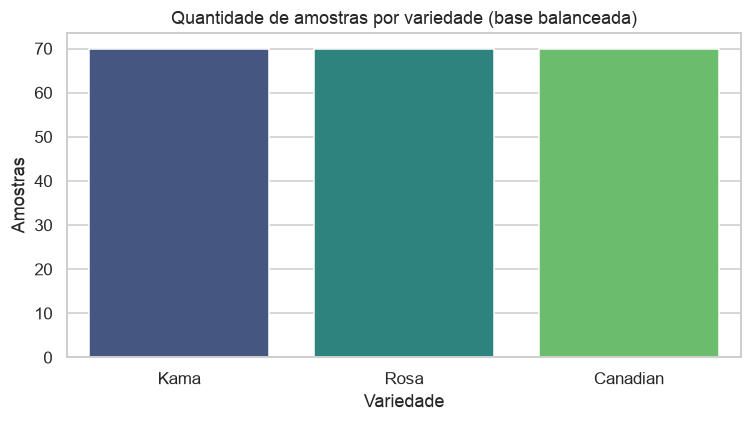

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
order = df["variedade"].value_counts().index
sns.countplot(x="variedade", data=df, order=order, palette="viridis", ax=ax)
ax.set_title("Quantidade de amostras por variedade (base balanceada)")
ax.set_xlabel("Variedade")
ax.set_ylabel("Amostras")
plt.tight_layout()
plt.show()

Confirma o balanceamento perfeito: 70 amostras para Kama, Rosa e Canadian. Isso
simplifica o treino e torna a comparação entre modelos justa.

### Gráfico 2 — Distribuições das variáveis numéricas

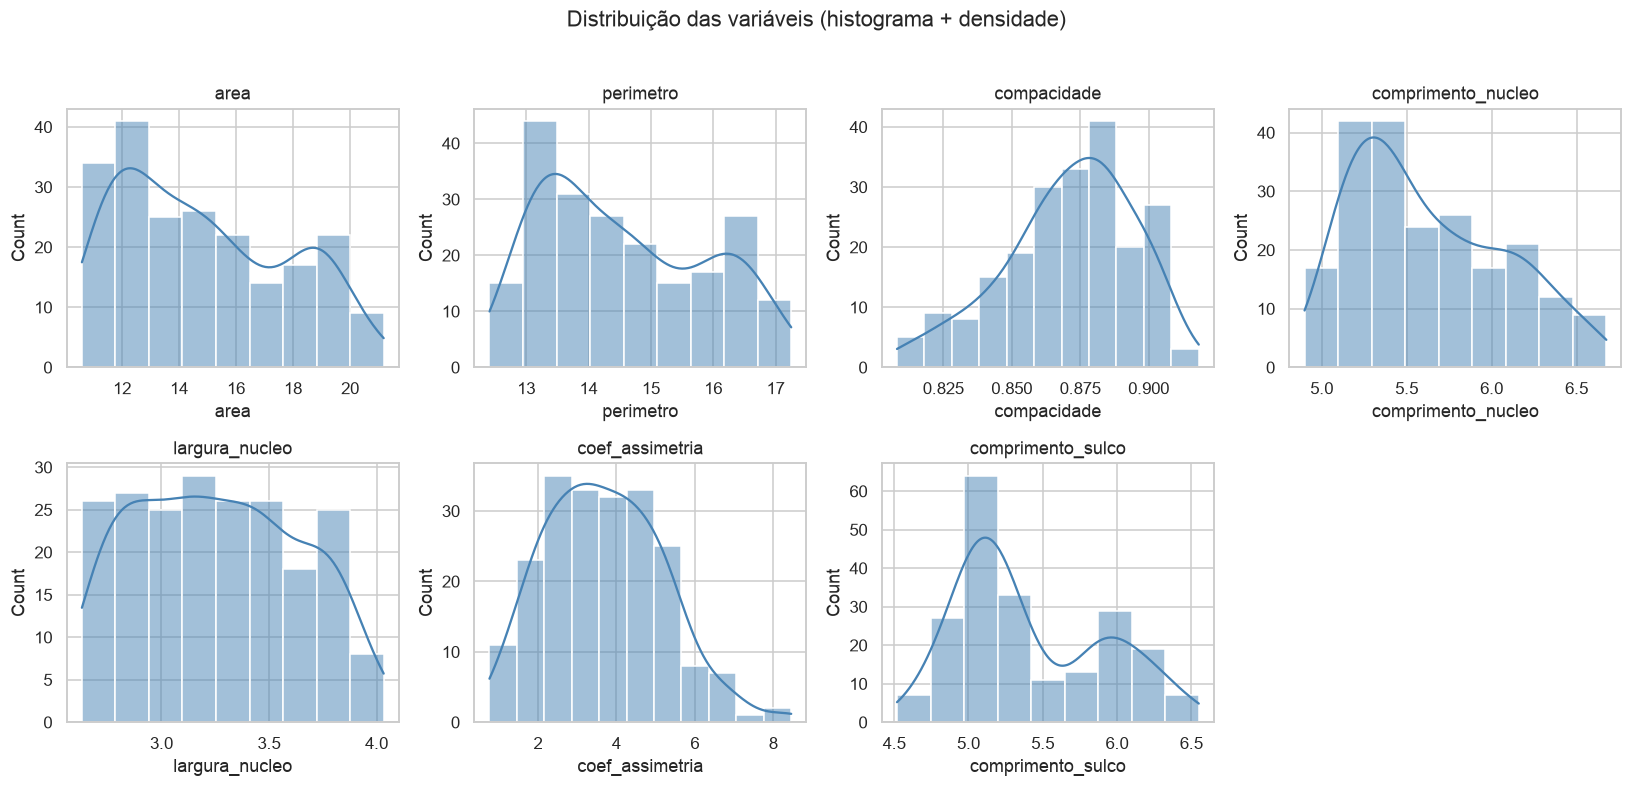

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for ax, col in zip(axes.flat, features):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(col)
axes.flat[-1].axis("off")
fig.suptitle("Distribuição das variáveis (histograma + densidade)", y=1.02)
plt.tight_layout()
plt.show()

- `area`, `perimetro`, `comprimento_nucleo` e `comprimento_sulco` exibem perfis
  **bimodais/multimodais** — sinal de que as variedades ocupam faixas distintas
  dessas medidas, o que favorece a separabilidade.
- `compacidade` e `largura_nucleo` são mais próximas de uma normal.
- `coef_assimetria` é levemente assimétrico à direita.

### Gráfico 3 — Variáveis segmentadas por variedade (boxplots)

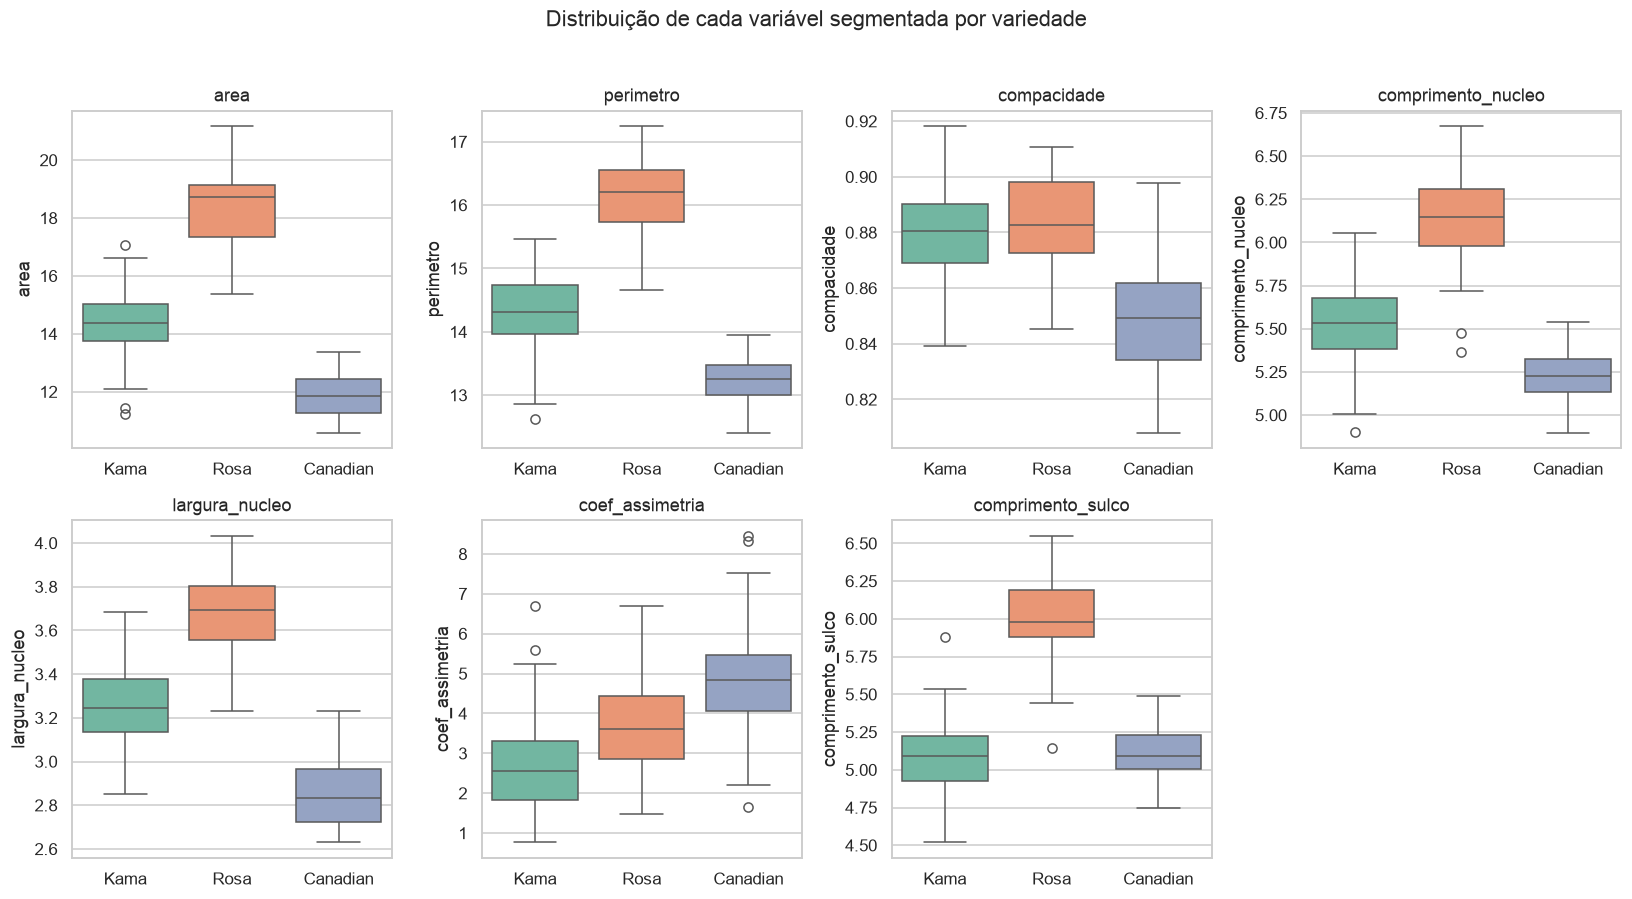

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
order = ["Kama", "Rosa", "Canadian"]
for ax, col in zip(axes.flat, features):
    sns.boxplot(x="variedade", y=col, data=df, order=order, palette="Set2", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
axes.flat[-1].axis("off")
fig.suptitle("Distribuição de cada variável segmentada por variedade", y=1.02)
plt.tight_layout()
plt.show()

Os boxplots mostram **separação clara em quase todas as medidas de tamanho**:
**Rosa** tem os maiores grãos (maior `area`, `perimetro` e `comprimento_nucleo`),
**Canadian** os menores, e **Kama** fica no meio. A `compacidade` separa pouco as
variedades, e o `coef_assimetria` é o atributo com maior sobreposição — pistas de
quais features serão mais (ou menos) discriminantes.

### Gráfico 4 — Correlação de Pearson entre as variáveis

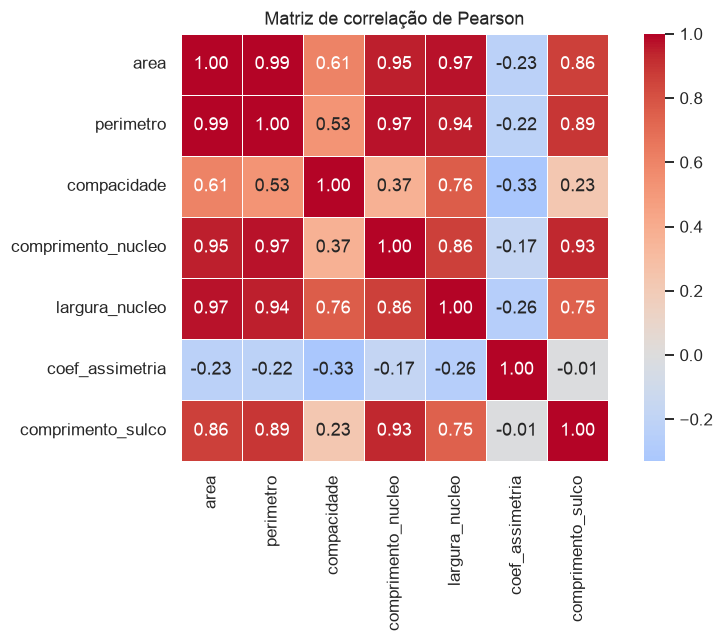

In [10]:
corr = df[features].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
    square=True, linewidths=0.5, ax=ax,
)
ax.set_title("Matriz de correlação de Pearson")
plt.tight_layout()
plt.show()

- Há **correlações muito altas** entre as medidas de tamanho: `area`, `perimetro`,
  `comprimento_nucleo` e `largura_nucleo` têm |r| > 0,8 entre si (`area`×`perimetro`
  ≈ 0,99). Isso indica **redundância/multicolinearidade** — uma única dimensão de
  "tamanho do grão" explica boa parte da variação.
- `coef_assimetria` é praticamente **descorrelacionado** das demais, agregando
  informação independente.
- A redundância justifica testar modelos robustos a multicolinearidade (árvores,
  SVM) e padronizar antes de modelos lineares.

### Gráfico 5 — Pairplot das variáveis por variedade

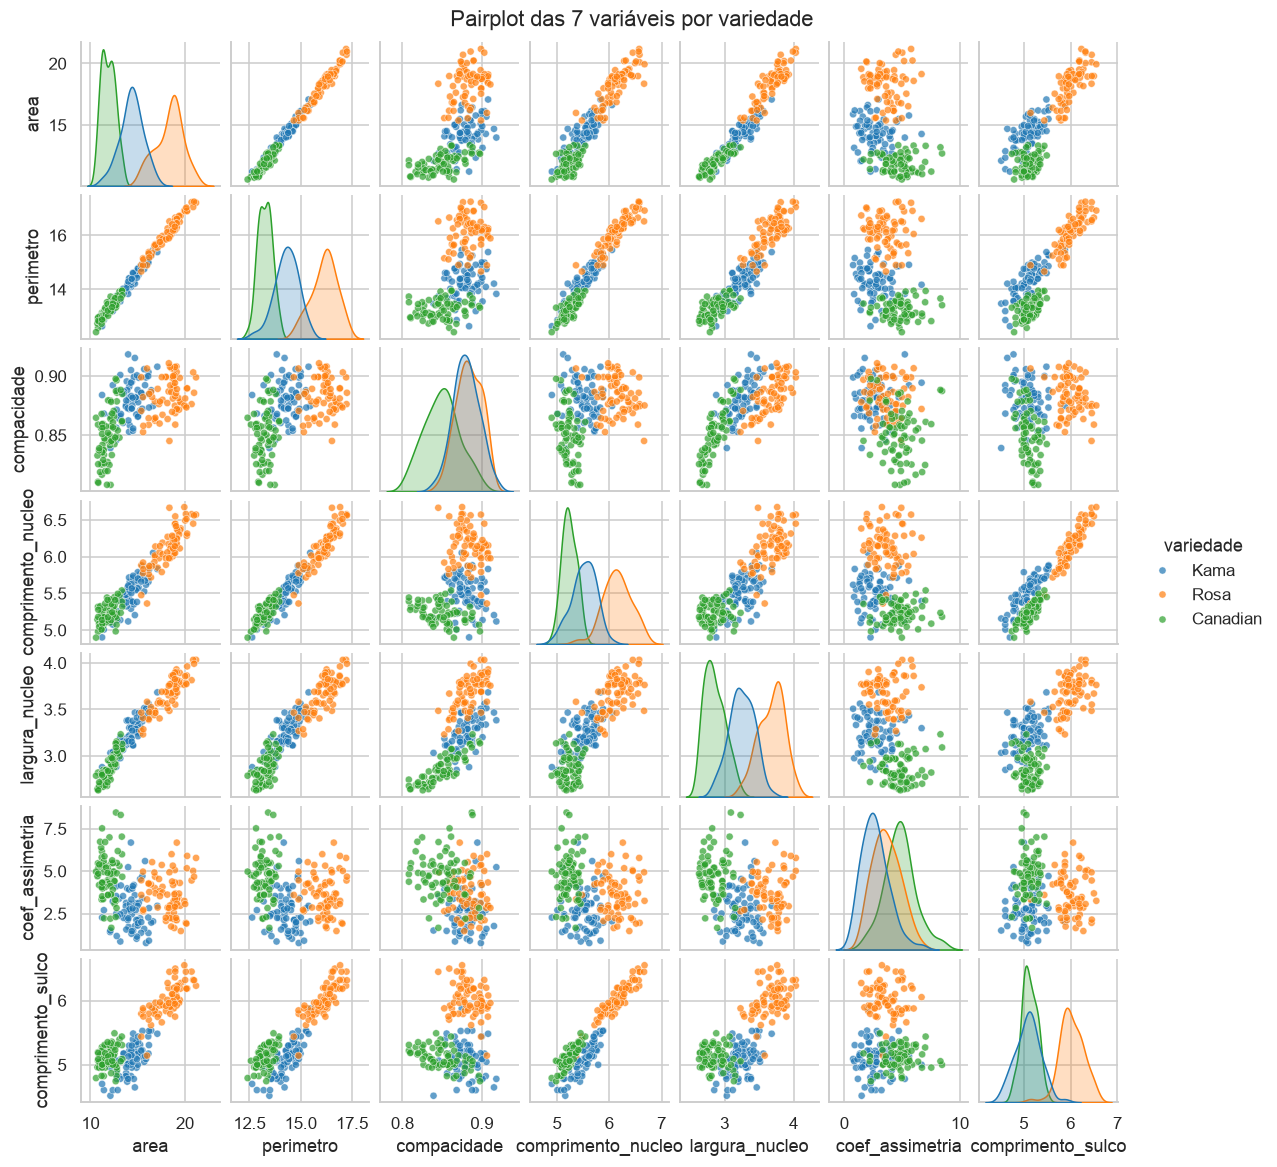

In [11]:
sns.pairplot(
    df[features + ["variedade"]],
    hue="variedade",
    hue_order=["Kama", "Rosa", "Canadian"],
    palette={"Kama": "#1f77b4", "Rosa": "#ff7f0e", "Canadian": "#2ca02c"},
    plot_kws={"alpha": 0.7, "s": 22},
    height=1.5,
)
plt.suptitle("Pairplot das 7 variáveis por variedade", y=1.01)
plt.show()

O pairplot evidencia que as três variedades formam **nuvens razoavelmente
separadas**, sobretudo nos pares envolvendo `area`, `perimetro` e
`comprimento_sulco`. As maiores sobreposições ocorrem entre **Kama e Rosa**;
**Canadian** aparece mais isolado (grãos menores e mais compactos). Essa
separabilidade antecipa boa acurácia para os classificadores.

### Gráfico 6 — Dispersão: área × comprimento do sulco

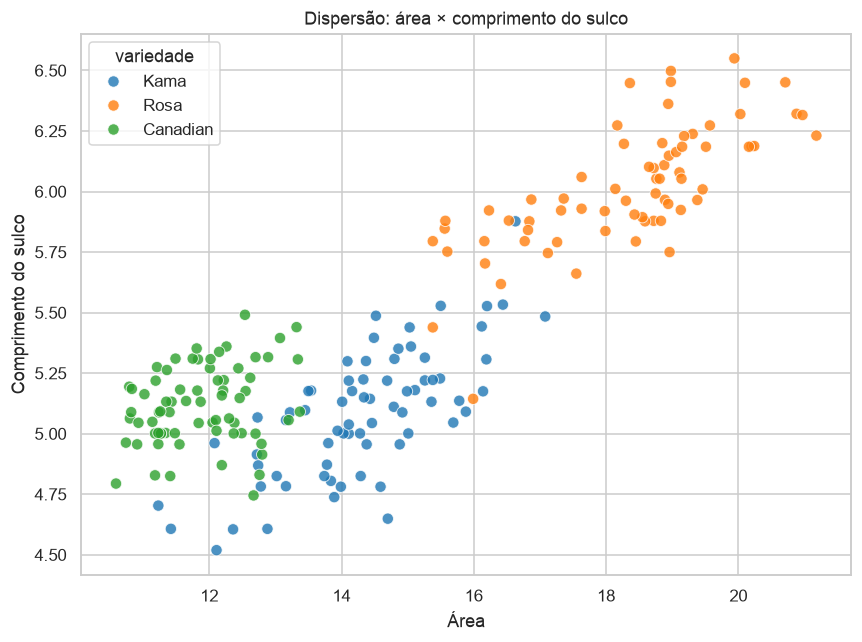

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=df, x="area", y="comprimento_sulco", hue="variedade",
    hue_order=["Kama", "Rosa", "Canadian"],
    palette={"Kama": "#1f77b4", "Rosa": "#ff7f0e", "Canadian": "#2ca02c"},
    s=55, alpha=0.8, ax=ax,
)
ax.set_title("Dispersão: área × comprimento do sulco")
ax.set_xlabel("Área")
ax.set_ylabel("Comprimento do sulco")
plt.tight_layout()
plt.show()

Apenas duas variáveis (`area` e `comprimento_sulco`) já quase separam as três
variedades linearmente — Canadian no canto inferior-esquerdo (grãos pequenos,
sulco curto) e Rosa no superior-direito. Isso reforça que o problema é, em grande
parte, **linearmente separável**.

## 4. Preparação dos dados (pré-processamento)

**Decisões de pré-processamento:**

- **Valores ausentes:** nenhum (verificado na seção 2) — nada a tratar.
- **Escalonamento:** as features têm magnitudes muito diferentes. Algoritmos
  baseados em distância (**KNN**, **SVM**) e em regularização (**Logistic
  Regression**) são sensíveis à escala, então aplicamos **padronização**
  (`StandardScaler`: média 0, desvio 1). Para Random Forest e Naive Bayes a
  padronização é inócua, mas a mantemos por uniformidade.
- **Anti-vazamento (*data leakage*):** o `StandardScaler` é encaixado em um
  `Pipeline`, de modo que o ajuste da escala usa **apenas o conjunto de treino**
  dentro de cada *fold* da validação cruzada.

Definimos a matriz de atributos `X` (as 7 medidas físicas) e o alvo `y`
(`variedade`).

In [13]:
X = df[features].copy()
y = df["variedade"].copy()

print("X:", X.shape, "| y:", y.shape)
print("Classes:", sorted(y.unique()))

X: (210, 7) | y: (210,)
Classes: ['Canadian', 'Kama', 'Rosa']


## 5. Modelagem — comparação de algoritmos

### Separação treino/teste (70/30)

Conforme o enunciado, separamos **70% para treino e 30% para teste**, de forma
**estratificada** (preservando a proporção das três variedades).

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
print("Treino:", X_train.shape, " Teste:", X_test.shape)
print("Distribuição no treino:", y_train.value_counts().to_dict())
print("Distribuição no teste: ", y_test.value_counts().to_dict())

Treino: (147, 7)  Teste: (63, 7)
Distribuição no treino: {'Canadian': 49, 'Rosa': 49, 'Kama': 49}
Distribuição no teste:  {'Kama': 21, 'Rosa': 21, 'Canadian': 21}


### Treino e avaliação dos cinco algoritmos

Escolhemos **cinco** algoritmos de famílias diferentes (o enunciado pede no
mínimo três): **KNN**, **SVM**, **Random Forest**, **Naive Bayes** e **Logistic
Regression**. Cada um é encapsulado em um `Pipeline` com `StandardScaler` e
avaliado de duas formas:

- **Validação cruzada estratificada (5 folds)** sobre o treino — estima a
  estabilidade do modelo.
- **Conjunto de teste (30% holdout)** — mede o desempenho final com **acurácia,
  precisão (macro), recall (macro) e F1 (macro)**.

In [15]:
modelos = {
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "SVM (RBF)": SVC(kernel="rbf", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
resultados = []
modelos_treinados = {}

for nome, estimator in modelos.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("clf", estimator)])

    cv_scores = cross_validate(
        pipe, X_train, y_train, cv=cv,
        scoring=["accuracy", "f1_macro"], n_jobs=-1,
    )

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    resultados.append({
        "modelo": nome,
        "cv_accuracy_mean": cv_scores["test_accuracy"].mean(),
        "cv_f1_macro_mean": cv_scores["test_f1_macro"].mean(),
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_precision_macro": precision_score(y_test, y_pred, average="macro"),
        "test_recall_macro": recall_score(y_test, y_pred, average="macro"),
        "test_f1_macro": f1_score(y_test, y_pred, average="macro"),
    })
    modelos_treinados[nome] = (pipe, y_pred)

resumo = pd.DataFrame(resultados).set_index("modelo").round(4)
resumo.sort_values("test_f1_macro", ascending=False)

,cv_accuracy_mean,cv_f1_macro_mean,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro
modelo,,,,,,
Logistic Regression,0.9453,0.9458,0.9048,0.9048,0.9048,0.9048
KNN (k=5),0.9115,0.9103,0.8889,0.8887,0.8889,0.8885
SVM (RBF),0.9391,0.9374,0.8889,0.8887,0.8889,0.8885
Random Forest,0.9317,0.9317,0.8413,0.8415,0.8413,0.8402
Naive Bayes,0.9320,0.9314,0.8413,0.8415,0.8413,0.8402


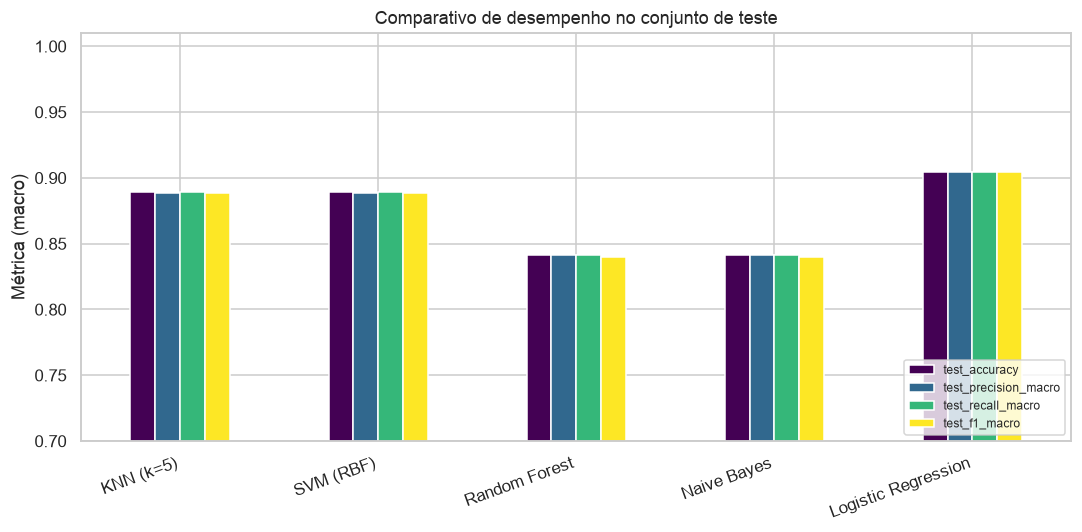

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = resumo[["test_accuracy", "test_precision_macro",
                  "test_recall_macro", "test_f1_macro"]].copy()
plot_df.plot(kind="bar", ax=ax, colormap="viridis")
ax.set_ylim(0.7, 1.01)
ax.set_title("Comparativo de desempenho no conjunto de teste")
ax.set_ylabel("Métrica (macro)")
ax.set_xlabel("")
ax.legend(loc="lower right", fontsize=8)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### Relatórios detalhados e matrizes de confusão

Exibimos o `classification_report` completo e a matriz de confusão do **modelo
vencedor** (maior F1 macro no teste) e do **Naive Bayes** (baseline simples e
rápido), para verificar em quais variedades os erros se concentram.

In [17]:
def plot_confusion(nome: str, y_pred) -> None:
    classes = ["Kama", "Rosa", "Canadian"]
    cm = confusion_matrix(y_test, y_pred, labels=classes)
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=classes, yticklabels=classes, cbar=False, ax=ax,
    )
    ax.set_title(f"Matriz de confusão — {nome}")
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")
    plt.tight_layout()
    plt.show()

>>> Modelo vencedor (antes do tuning): Logistic Regression

              precision    recall  f1-score   support

    Canadian      0.905     0.905     0.905        21
        Kama      0.857     0.857     0.857        21
        Rosa      0.952     0.952     0.952        21

    accuracy                          0.905        63
   macro avg      0.905     0.905     0.905        63
weighted avg      0.905     0.905     0.905        63



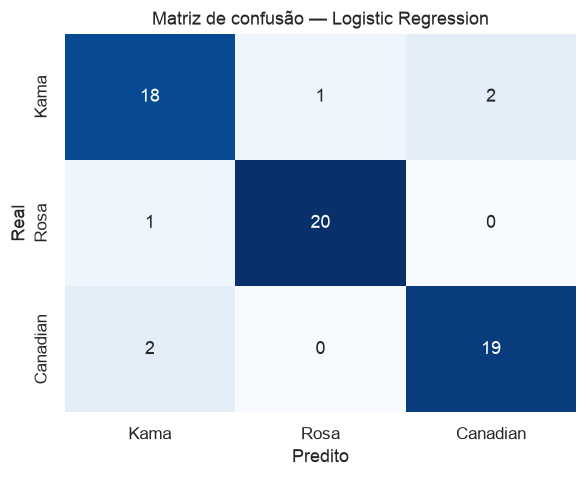

In [18]:
melhor = resumo["test_f1_macro"].idxmax()
print(f">>> Modelo vencedor (antes do tuning): {melhor}\n")
print(classification_report(y_test, modelos_treinados[melhor][1], digits=3))
plot_confusion(melhor, modelos_treinados[melhor][1])

>>> Naive Bayes (baseline)

              precision    recall  f1-score   support

    Canadian      0.783     0.857     0.818        21
        Kama      0.789     0.714     0.750        21
        Rosa      0.952     0.952     0.952        21

    accuracy                          0.841        63
   macro avg      0.841     0.841     0.840        63
weighted avg      0.841     0.841     0.840        63



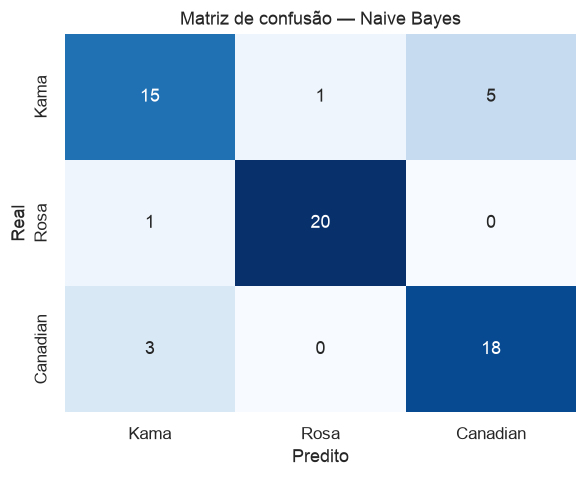

In [19]:
print(">>> Naive Bayes (baseline)\n")
print(classification_report(y_test, modelos_treinados["Naive Bayes"][1], digits=3))
plot_confusion("Naive Bayes", modelos_treinados["Naive Bayes"][1])

## 6. Otimização dos modelos (GridSearchCV)

Aplicamos **busca em grade** (`GridSearchCV`, 5 folds estratificados, otimizando
`f1_macro`) aos três modelos cujo desempenho mais depende de hiperparâmetros:
**KNN**, **SVM** e **Random Forest**. Cada grade é avaliada dentro de um
`Pipeline` com `StandardScaler`, garantindo que a padronização seja reajustada em
cada *fold* (sem vazamento).

In [20]:
grids = {
    "KNN (k=5)": (
        Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier())]),
        {
            "clf__n_neighbors": [3, 5, 7, 9, 11, 15],
            "clf__weights": ["uniform", "distance"],
            "clf__p": [1, 2],
        },
    ),
    "SVM (RBF)": (
        Pipeline([("scaler", StandardScaler()), ("clf", SVC(random_state=RANDOM_STATE))]),
        {
            "clf__C": [0.1, 1, 10, 100],
            "clf__gamma": ["scale", "auto", 0.01, 0.1, 1],
            "clf__kernel": ["rbf", "linear"],
        },
    ),
    "Random Forest": (
        Pipeline([("scaler", StandardScaler()),
                  ("clf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))]),
        {
            "clf__n_estimators": [100, 200, 400],
            "clf__max_depth": [None, 4, 6, 8],
            "clf__min_samples_split": [2, 5, 10],
        },
    ),
}

otimizados = {}
linhas_tuning = []

for nome, (pipe, grade) in grids.items():
    gs = GridSearchCV(pipe, grade, cv=cv, scoring="f1_macro", n_jobs=-1)
    gs.fit(X_train, y_train)

    y_pred = gs.best_estimator_.predict(X_test)
    otimizados[nome] = (gs.best_estimator_, y_pred)

    linhas_tuning.append({
        "modelo": nome,
        "melhores_parametros": gs.best_params_,
        "cv_f1_macro_tuned": gs.best_score_,
        "test_accuracy_tuned": accuracy_score(y_test, y_pred),
        "test_f1_macro_tuned": f1_score(y_test, y_pred, average="macro"),
    })

for linha in linhas_tuning:
    print(f"{linha['modelo']}: {linha['melhores_parametros']}")

KNN (k=5): {'clf__n_neighbors': 3, 'clf__p': 1, 'clf__weights': 'uniform'}
SVM (RBF): {'clf__C': 1, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
Random Forest: {'clf__max_depth': None, 'clf__min_samples_split': 5, 'clf__n_estimators': 400}


### Comparação antes × depois do tuning

A tabela abaixo confronta o F1 macro no teste **antes** (configuração padrão) e
**depois** da otimização, evidenciando se a busca em grade trouxe ganho relevante.

In [21]:
tuning_df = pd.DataFrame(linhas_tuning).set_index("modelo")

comparativo = pd.DataFrame({
    "test_f1_antes": resumo.loc[tuning_df.index, "test_f1_macro"],
    "test_f1_depois": tuning_df["test_f1_macro_tuned"],
    "test_acc_antes": resumo.loc[tuning_df.index, "test_accuracy"],
    "test_acc_depois": tuning_df["test_accuracy_tuned"],
})
comparativo["ganho_f1"] = comparativo["test_f1_depois"] - comparativo["test_f1_antes"]
comparativo.round(4)

,test_f1_antes,test_f1_depois,test_acc_antes,test_acc_depois,ganho_f1
modelo,,,,,
KNN (k=5),0.8885,0.9055,0.8889,0.9048,0.017
SVM (RBF),0.8885,0.8885,0.8889,0.8889,-0.000
Random Forest,0.8402,0.8402,0.8413,0.8413,-0.000


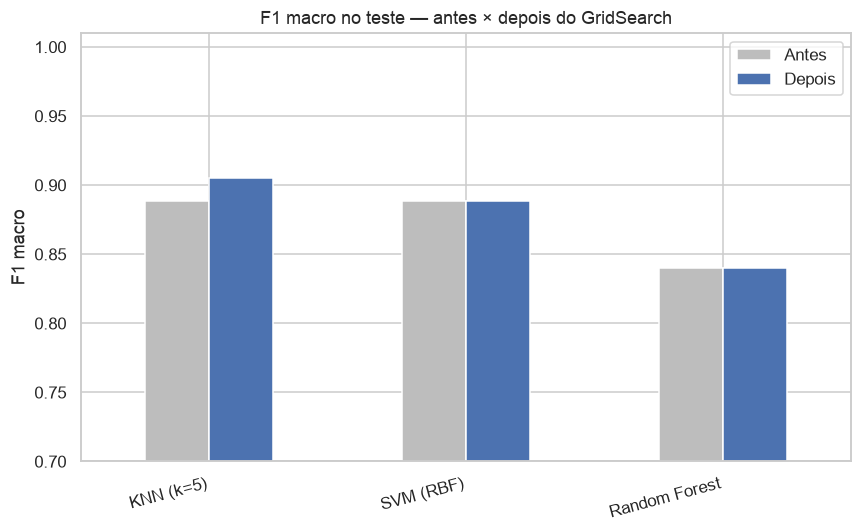

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
comparativo[["test_f1_antes", "test_f1_depois"]].plot(
    kind="bar", ax=ax, color=["#bdbdbd", "#4c72b0"]
)
ax.set_ylim(0.7, 1.01)
ax.set_title("F1 macro no teste — antes × depois do GridSearch")
ax.set_ylabel("F1 macro")
ax.set_xlabel("")
ax.legend(["Antes", "Depois"])
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

>>> Melhor modelo otimizado: KNN (k=5)

              precision    recall  f1-score   support

    Canadian      0.864     0.905     0.884        21
        Kama      0.857     0.857     0.857        21
        Rosa      1.000     0.952     0.976        21

    accuracy                          0.905        63
   macro avg      0.907     0.905     0.905        63
weighted avg      0.907     0.905     0.905        63



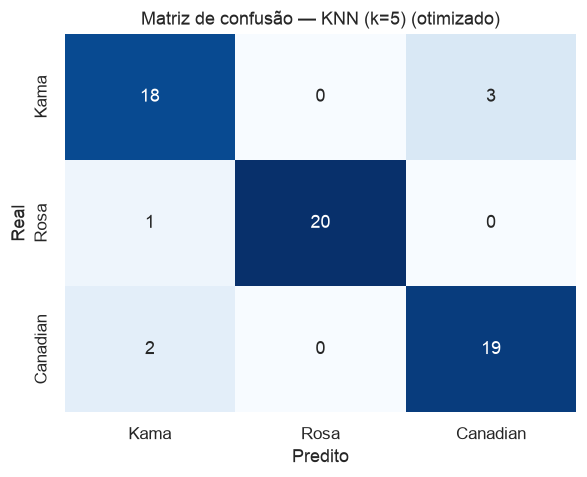

In [23]:
melhor_otim = comparativo["test_f1_depois"].idxmax()
print(f">>> Melhor modelo otimizado: {melhor_otim}\n")
print(classification_report(y_test, otimizados[melhor_otim][1], digits=3))
plot_confusion(f"{melhor_otim} (otimizado)", otimizados[melhor_otim][1])

### Importância das variáveis (Random Forest)

A importância de features do Random Forest revela quais medidas mais pesaram nas
decisões — uma forma de interpretar o que diferencia as variedades.

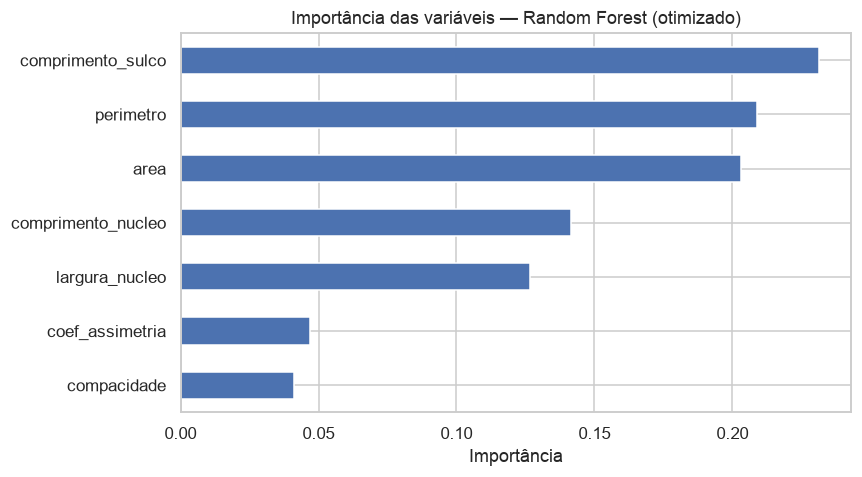

comprimento_sulco     0.232
perimetro             0.209
area                  0.203
comprimento_nucleo    0.141
largura_nucleo        0.127
coef_assimetria       0.047
compacidade           0.041
dtype: float64

In [24]:
rf_pipe = otimizados["Random Forest"][0]
rf = rf_pipe.named_steps["clf"]
importancias = pd.Series(rf.feature_importances_, index=features).sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
importancias.plot(kind="barh", color="#4c72b0", ax=ax)
ax.set_title("Importância das variáveis — Random Forest (otimizado)")
ax.set_xlabel("Importância")
plt.tight_layout()
plt.show()

importancias.sort_values(ascending=False).round(3)

## 7. Interpretação dos resultados e conclusões

**Desempenho dos modelos**

- Todos os classificadores atingem **bom desempenho** (acurácia na validação
  cruzada ~0,91–0,95 e ~0,84–0,90 no teste), confirmando a separabilidade vista na
  EDA. A **Logistic Regression** lidera antes do tuning, com **KNN** e **SVM** logo
  atrás — coerente com o caráter quase linearmente separável após a padronização.
- O conjunto de teste tem apenas **63 amostras** (30% de 210), então cada erro
  pesa ~1,6%: por isso a acurácia de teste oscila mais que a da validação cruzada,
  que é a estimativa mais estável.
- A **otimização por GridSearch** melhora o **KNN** (F1 de ~0,889 para ~0,906,
  com `n_neighbors=3`, distância de Manhattan) e mantém SVM e Random Forest
  praticamente estáveis — os ganhos são modestos porque a base é pequena e o teto
  do problema já é alto.
- As matrizes de confusão mostram que os poucos erros se concentram no par
  **Kama × Rosa**, justamente as variedades de tamanho intermediário/grande com
  maior sobreposição; **Canadian** é classificada praticamente sem erro.

**Variáveis mais relevantes**

- O Random Forest aponta as medidas de **tamanho** — `area`, `perimetro`,
  `comprimento_nucleo` e `comprimento_sulco` — como as mais discriminantes,
  coerente com os boxplots. `compacidade` e `coef_assimetria` contribuem menos.
- Como `area`, `perimetro` e os comprimentos são fortemente correlacionados, há
  redundância: poucas dimensões de "tamanho" já carregam a maior parte do sinal.

**Aplicação ao contexto da cooperativa**

- Um modelo simples (SVM ou Logistic Regression) já automatiza a triagem das três
  variedades com alta confiabilidade, reduzindo o esforço manual e o erro humano.
- Para produção, recomenda-se um **SVM/LogReg padronizado** pela combinação de
  acurácia, rapidez de inferência e baixo custo, mantendo o Random Forest como
  alternativa interpretável (via *feature importances*).

**Pontos fortes do trabalho**

- Pipeline 100% reprodutível (semente fixa, *split* estratificado, CV
  estratificada e `StandardScaler` dentro de `Pipeline` — sem *data leakage*).
- Comparação justa entre cinco famílias de algoritmos com múltiplas métricas.
- Otimização explícita com `GridSearchCV` e comparação **antes × depois**.

**Limitações**

- A base é **pequena (210 amostras)**, o que aumenta a variância das estimativas
  e limita a generalização.
- Há **apenas medidas geométricas** do grão; cor, textura, peso e teor de umidade
  poderiam melhorar a discriminação em cenários reais.
- As amostras vêm de uma coleta controlada; grãos danificados, sujeira ou
  variação de safra/região não estão representados.

**Próximos passos sugeridos**

- Coletar mais amostras e validar em base externa para checar generalização.
- Testar redução de dimensionalidade (PCA) dada a alta multicolinearidade.
- Avaliar *ensembles* adicionais (Gradient Boosting/XGBoost) e calibrar
  probabilidades para apoiar decisões de classificação com nível de confiança.